# **Marketing Campaign Results**

_This data project has been used as a take-home assignment in the recruitment process for the data science positions at Freedom Debt Relief._

Freedom Debt Relief’s customers are people who have a substantial amount of debt and because of an unexpected hardship, are no longer able to make their minimum monthly payments. Upon enrolling in Freedom’s Debt Relief program, customers cease making payments to their creditors and instead make deposits they can afford into a new dedicated bank account with Freedom. Freedom uses these funds to negotiate with each of the client’s creditors to settle the debt, typically at only a fraction of what was originally owed. Once a settlement has been agreed upon for an individual account, Freedom facilitates payments from the dedicated bank account to the creditor based on the terms of the settlement agreement. Freedom then collects fees from the client for the individual account that was settled. Freedom earns fees for each account it successfully negotiates a settlement agreement. The number of settlement agreements Freedom can negotiate is proportional to the monthly deposited amount. Assume industry statistics for any analysis input that you would want to use that is not provided here, including but not limited to fee percentage Freedom would collect along with ongoing cost per client between initial enrollment and program graduation.

Assignment
----------

Imagine that Freedom ran a recent marketing campaign to promote the value proposition of how the debt relief program helps people achieve financial freedom. Assume the cost of this campaign was $5 million. There are five months of data in the datasets provided. Let’s say campaign took place over the course of the third month. You now want to show the marketing, sales and operations teams just how successful this campaign was.

Using the three datasets given:

1.  Provide a quantitative assessment of whether the marketing campaign was successful. How and why did you choose your specific success metric(s)?
2.  Based on the provided data, how would you recommend campaign strategy be adjusted in the future to improve performance?
3.  How do you think campaign performance would have changed if we did not run the campaign in Month 3, but instead postponed it until month 6? Provide an incremental number versus your result in Question #1.

Data Description
----------------

Attached you will find three files with the data you will need to complete the analysis.

`client_data.csv`: You will find data specific to fictional clients

*   `client_id`: Randomly generated unique surrogate identifier for a client
*   `client_geographical_region`: Client geographical location in relation to U.S. Census definitions
*   `client_residence_status`: Client residence status in relation to whether they rent or own
*   `client_age`: Client age in relation to date of birth

`deposit_data.csv`: You will find data specific to the client deposit behavior

*   `client_id`: Randomly generated unique surrogate identifier for a client
*   `deposit_type`: Delineates whether a client deposit is the scheduled record or actual record
*   `deposit_amount`: Client deposit amount to the dedicated bank account with Freedom
*   `deposit_cadence`: Timing and pattern of client deposit activity
*   `deposit_date`: Deposit date for deposit type

`calendar_data.csv`: This is a calendar reference table

*   `gregorian_date`: This date aligns with the Gregorian calendar
*   `month_name`: These are the designated months in the case study
    *   Month 1 and 2 are pre-campaign
    *   Month 3 is the campaign
    *   Month 4 and 5 are post-campaign

_Note: These datasets were created for this analytical exercise and are only intended to be used to assess the critical thinking and technical abilities of interview candidates. This data purposely does not reflect actual client or deposit information. No inferences should be made from this information in regard to Freedom’s client base, deposit activity, company size or company growth trajectory._

Practicalities
--------------

You are free to use any tool or means you would like to highlight your abilities, but we would like to see something more advanced than Excel pivot tables, for example. Not only your ability to provide the correct results is important, but also how you decide to visualize and explain your results.

Assume the following:

*   There is no seasonality in the results, and the campaign spend was distributed evenly across Month 3 (i.e., spend on the first day is the same as spend on the last day).
*   Channel mix, targeting, and efficiency are outside the scope of this exercise, but you may address it after answering the 3 questions.
*   There may be data provided that is not useful in your analysis.

## Import Data & Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

client_data = pd.read_csv('datasets/client_data.csv')
deposit_data = pd.read_csv('datasets/deposit_data.csv')
calendar_data = pd.read_csv('datasets/calendar_data.csv')

df = client_data.merge(deposit_data, on='client_id').merge(calendar_data, left_on='deposit_date', right_on='gregorian_date', copy=False)

In [2]:
df = df.drop(columns='gregorian_date', axis=1)
df

,client_id,client_geographical_region,client_residence_status,client_age,deposit_type,deposit_amount,deposit_cadence,deposit_date,month_name
0,538839486596724,Northeast,Rent,91,Actual Deposit,10000.0,Extra,2019-07-11,Month 2
1,321708286091707,West,Own,83,Actual Deposit,200.0,Extra,2019-10-19,Month 5
2,321708286091707,West,Own,83,Actual Deposit,50.0,Extra,2019-08-26,Month 3
3,321708286091707,West,Own,83,Scheduled Deposit,200.0,Monthly,2019-08-01,Month 3
4,321708286091707,West,Own,83,Actual Deposit,200.0,Monthly,2019-09-01,Month 4
...,...,...,...,...,...,...,...,...,...
480389,137024861084246,West,Own,80,Scheduled Deposit,247.0,Biweekly,2019-09-04,Month 4
480390,137024861084246,West,Own,80,Actual Deposit,247.0,Biweekly,2019-09-18,Month 4
480391,137024861084246,West,Own,80,Scheduled Deposit,247.0,Biweekly,2019-09-18,Month 4
480392,137024861084246,West,Own,80,Actual Deposit,247.0,Biweekly,2019-10-06,Month 5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480394 entries, 0 to 480393
Data columns (total 9 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   client_id                   480394 non-null  int64  
 1   client_geographical_region  480394 non-null  object 
 2   client_residence_status     480394 non-null  object 
 3   client_age                  480394 non-null  int64  
 4   deposit_type                480394 non-null  object 
 5   deposit_amount              480394 non-null  float64
 6   deposit_cadence             480394 non-null  object 
 7   deposit_date                480394 non-null  object 
 8   month_name                  480394 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 33.0+ MB


### Check for Missing Data

In [4]:
def missing_data(input_data):
    total = input_data.isnull().sum()
    percent = (input_data.isnull().sum() / input_data.isnull().count() * 100)
    table = pd.concat([total, percent], axis = 1, keys = ['Total', 'Percent'])
    types = []
    for col in input_data.columns:
        dtype = str(input_data[col].dtype)
        types.append(dtype)
    table["Types"] = types
    return(pd.DataFrame(table))

missing_data(df)

,Total,Percent,Types
client_id,0,0.0,int64
client_geographical_region,0,0.0,object
client_residence_status,0,0.0,object
client_age,0,0.0,int64
deposit_type,0,0.0,object
deposit_amount,0,0.0,float64
deposit_cadence,0,0.0,object
deposit_date,0,0.0,object
month_name,0,0.0,object


### Check frequency in each data 

In [5]:
def value_cnt_norm_cal(df,feature):
    ftr_value_cnt = df[feature].value_counts()
    ftr_value_cnt_norm = df[feature].value_counts(normalize=True) * 100
    ftr_value_cnt_concat = pd.concat([ftr_value_cnt, ftr_value_cnt_norm], axis=1)
    ftr_value_cnt_concat.columns = ['Count', 'Frequency (%)']
    print("\n")
    return ftr_value_cnt_concat

def gen_info_feat(df, feature, col_type='category'):
    print(f"Feature: {feature}")
    print('Description:\n', df[feature].describe())
    print('*' * 50)
    print(f'Object type: {df[feature].dtype}')
    print('*' * 50)

    if col_type == 'category':
        print('Value Count and Frequency:\n', value_cnt_norm_cal(df, feature))

In [6]:
value_cnt_norm_cal(df, 'client_geographical_region')

,Count,Frequency (%)
client_geographical_region,,
West,205629,42.804240
South,108004,22.482379
Midwest,88185,18.356807
Northeast,78576,16.356574


In [7]:
value_cnt_norm_cal(df, 'client_residence_status')

,Count,Frequency (%)
client_residence_status,,
Own,345432,71.905977
Rent,134962,28.094023


In [8]:
value_cnt_norm_cal(df, 'deposit_type')

,Count,Frequency (%)
deposit_type,,
Scheduled Deposit,247986,51.621377
Actual Deposit,232408,48.378623


In [9]:
value_cnt_norm_cal(df, 'deposit_cadence')

,Count,Frequency (%)
deposit_cadence,,
Monthly,262858,54.717170
Biweekly,209189,43.545298
Extra,8347,1.737532


In [10]:
value_cnt_norm_cal(df, 'month_name')

,Count,Frequency (%)
month_name,,
Month 3,108505,22.586668
Month 4,107494,22.376216
Month 5,106363,22.140784
Month 2,80205,16.695671
Month 1,77827,16.200660


In [11]:
gen_info_feat(df, 'client_age')

Feature: client_age
Description:
 count    480394.000000
mean         52.192469
std          13.773928
min          21.000000
25%          41.000000
50%          52.000000
75%          62.000000
max         105.000000
Name: client_age, dtype: float64
**************************************************
Object type: int64
**************************************************


Value Count and Frequency:
             Count  Frequency (%)
client_age                      
50          12971       2.700075
53          12957       2.697161
51          12641       2.631382
52          12494       2.600782
59          12231       2.546035
...           ...            ...
98             12       0.002498
103            10       0.002082
105            10       0.002082
101            10       0.002082
21              6       0.001249

[81 rows x 2 columns]


In [12]:
gen_info_feat(df, 'deposit_amount')

Feature: deposit_amount
Description:
 count    480394.000000
mean        365.207130
std         346.644434
min           0.010000
25%         200.000000
50%         290.000000
75%         452.000000
max       30000.000000
Name: deposit_amount, dtype: float64
**************************************************
Object type: float64
**************************************************


Value Count and Frequency:
                 Count  Frequency (%)
deposit_amount                      
200.00          17399       3.621819
100.00          14718       3.063735
300.00           5202       1.082861
250.00           4364       0.908421
500.00           3745       0.779568
...               ...            ...
136.62              1       0.000208
1723.13             1       0.000208
2617.37             1       0.000208
2560.00             1       0.000208
17.91               1       0.000208

[2477 rows x 2 columns]


### Change date column type to a datetime object

In [13]:
df['deposit_date'] = pd.to_datetime(df['deposit_date'])

df['deposit_date'].min(), df['deposit_date'].max()

(Timestamp('2019-06-01 00:00:00'), Timestamp('2019-10-31 00:00:00'))

## Question #1

**Provide a quantitative assessment of whether the marketing campaign was successful. How and why did you choose your specific success metric(s)?**

This question can already be answered from the plots in the previous sections, especially the ones that show the deposit amount per month. We know that the ad campaign was running during the 3rd month of our data set (which is Month 8 in the current year, i.e., August). A huge spike can be noticed in the line plot titled "Deposit amount per month" between months 7 & 8, i.e., while the campaign was running. Since then, the deposit amount has been slowly decreasing but has remained at very higher levels than before the campaign. To put this into numbers:

- During the month the campaign was running, Freedom Debt Relief received almost $10 million dollars increase in deposit amounts than previous months

- In the months following the campaign, the total deposit amount starts to slowly decrease, but is still at higher levels than before the ad campaign: $8.5 million in the month immediately following the campaign, and $8 million in the last month of the data

- The cost of the campaign was $5 million, and the incurred deposit amount increased by a total of $26.5 million. A quick Google search for "freedom debt relief pricing" reveals an 18-25% fee incurred by the company for its services. We would assume that this is based on the residence status and the deposit cadence, but neither the data nor the task description provide any estimate or hint to this. Assuming the lowest, 18% fee for all clients, we observe an increase in profits to $4.77 million (26.5M * 18%). While this looks like a loss of $230K for the campaign, it is important to note that the trend shows this would have been much higher without the campaign, and it is very unlikely that the minimum fee is applied to all clients, so this number should be treated as the most pessimistic estimate.

Another quantitative assessment that we can make is to see the number of new clients that were brought in during and after the market campaign.

In [14]:
clients_before_campaign = df[df['month_name'].isin(['Month 1', 'Month 2'])]['client_id'].unique()
clients_before_campaign.shape

(34051,)

In [15]:
clients_during_campaign = df[df['month_name'] == 'Month 3']['client_id'].unique()
clients_during_campaign.shape

(43806,)

In [16]:
clients_after_campaign = df[df['month_name'].isin(['Month 4', 'Month 5'])]['client_id'].unique()
clients_after_campaign.shape

(41862,)

**Question**: How many new clients were acquired while the ad campaign was running?

New client is one that has made his first deposit while the campaign was running.

In [17]:
len(set(clients_during_campaign).difference(set(clients_before_campaign)))

11544

Question: How many after the campaign?

In [18]:
len(set(clients_after_campaign).difference(set(clients_before_campaign).union(set(clients_during_campaign))))

752

Another interesting insight that we can calculate is to see how the number of scheduled and actual deposits changes over time.

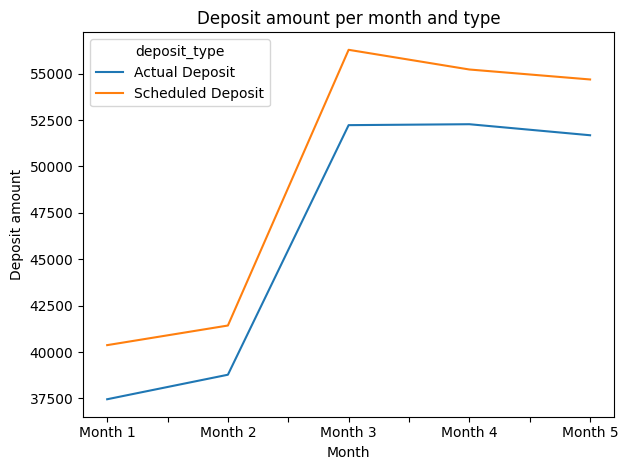

In [19]:
temp_df = df.groupby(by=[df["deposit_type"], df["month_name"]])["deposit_type"].count()

ax = temp_df.unstack(level=0).plot(kind='line')

ax.set_xlabel("Month")
ax.set_ylabel("Deposit amount")
ax.set_title("Deposit amount per month and type")
plt.tight_layout()

As expected, this plot very closely matches the distributions of the plots in the analysis section. During the ad campaign, the number of actual and scheduled deposits increases for ```25%```, or ```10K``` transactions, and while it gradually decreases in the next two months, it still remains very high, at above 50K deposits per type each, while the pre-campaign levels were at around 40K.

## Question 2

**Based on the provided data, how would you recommend campaign strategy be adjusted in the future to improve performance?**

Almost all of the plots show similar patterns through time and it is difficult to make any suggestions.

One thing that could be explored more is targeted marketing. We notice that most of the people in the data are middle-aged (40-60 years) and most of them are home owners. We can observe this in the age histogram and the count per residence status in the EDA section.

In the next plot, we will show the deposit amount changing through time and age group (age divided by 10).

In [20]:
def discretize_age(row):
    return int(row.client_age / 10)

dff = df.copy(deep=True)
dff["age_group"] = dff.apply(discretize_age, axis=1)
dff

,client_id,client_geographical_region,client_residence_status,client_age,deposit_type,deposit_amount,deposit_cadence,deposit_date,month_name,age_group
0,538839486596724,Northeast,Rent,91,Actual Deposit,10000.0,Extra,2019-07-11,Month 2,9
1,321708286091707,West,Own,83,Actual Deposit,200.0,Extra,2019-10-19,Month 5,8
2,321708286091707,West,Own,83,Actual Deposit,50.0,Extra,2019-08-26,Month 3,8
3,321708286091707,West,Own,83,Scheduled Deposit,200.0,Monthly,2019-08-01,Month 3,8
4,321708286091707,West,Own,83,Actual Deposit,200.0,Monthly,2019-09-01,Month 4,8
...,...,...,...,...,...,...,...,...,...,...
480389,137024861084246,West,Own,80,Scheduled Deposit,247.0,Biweekly,2019-09-04,Month 4,8
480390,137024861084246,West,Own,80,Actual Deposit,247.0,Biweekly,2019-09-18,Month 4,8
480391,137024861084246,West,Own,80,Scheduled Deposit,247.0,Biweekly,2019-09-18,Month 4,8
480392,137024861084246,West,Own,80,Actual Deposit,247.0,Biweekly,2019-10-06,Month 5,8


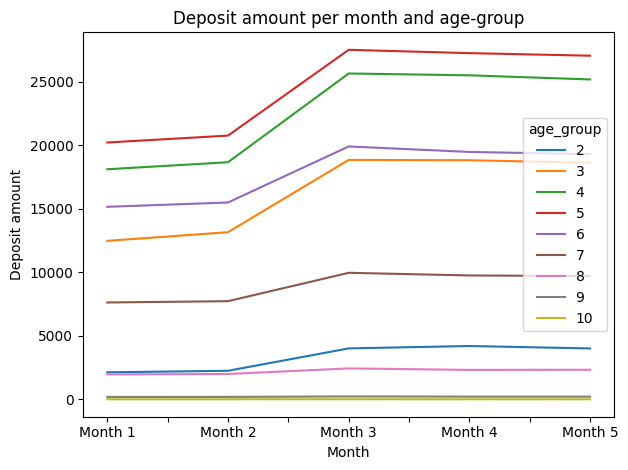

In [21]:
tmp_df = dff.groupby(by=[dff["age_group"], dff["month_name"]]).size()

ax = tmp_df.unstack(level=0).plot(kind='line')

ax.set_xlabel("Month")
ax.set_ylabel("Deposit amount")
ax.set_title("Deposit amount per month and age-group")
plt.tight_layout()

We observe big increase in middle-aged customers and little to no increase in very young or very old customers. In the following analysis, we focus on the middle-aged sub-group of customers. We think that better engagement with them could result in more deposits.

In [22]:
df_q2 = df[(df["client_residence_status"] == "Own") 
         & (df["client_age"] <= 60) 
         & (df["client_age"] >= 40)]
df_q2.shape

(181068, 9)

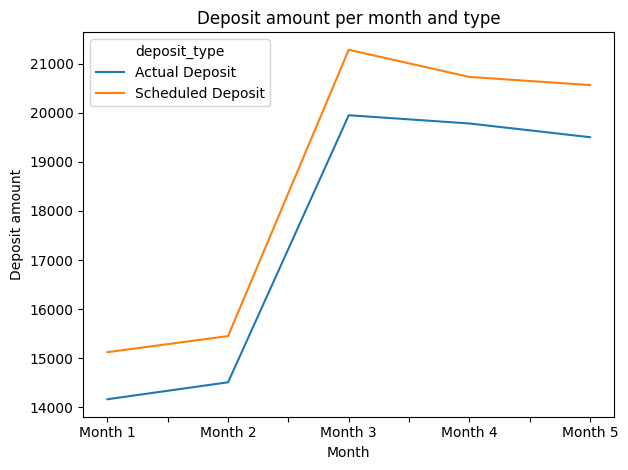

In [23]:
temp_df = df_q2.groupby(by=[df_q2["deposit_type"], df_q2["month_name"]])["deposit_type"].count()

ax = temp_df.unstack(level=0).plot(kind='line')
ax.set_xlabel("Month")
ax.set_ylabel("Deposit amount")
ax.set_title("Deposit amount per month and type")
plt.tight_layout()

This sub-group of customers is responsible for 42% of the extra deposit amount, and yet represents only 37% of clients.

In [24]:
extra_deposit_df_q2 = df_q2[df_q2["deposit_cadence"] == "Extra"]["deposit_amount"].sum()
extra_deposit_df = df[df["deposit_cadence"] == "Extra"]["deposit_amount"].sum()

extra_deposit_df_q2 / extra_deposit_df

0.4234867523021418

In [25]:
df_q2.shape[0] / df.shape[0]

0.3769156150992727

We can further explore the extra deposits to identify client groups that are of interest.

In [26]:
df[df["deposit_cadence"] == "Extra"]["client_geographical_region"].value_counts()

client_geographical_region
West         3570
South        1991
Midwest      1486
Northeast    1300
Name: count, dtype: int64

In [27]:
df[df["deposit_cadence"] == "Extra"]["client_residence_status"].value_counts()

client_residence_status
Own     5856
Rent    2491
Name: count, dtype: int64

In [28]:
df[df["deposit_cadence"] == "Extra"]["deposit_type"].value_counts()

deposit_type
Actual Deposit    8347
Name: count, dtype: int64

In [29]:
df[df["deposit_cadence"] == "Extra"]["month_name"].value_counts()

month_name
Month 3    2235
Month 4    1898
Month 5    1846
Month 2    1274
Month 1    1094
Name: count, dtype: int64

Some key points based on the previous cells:

- Most extra deposits are observed in the West region as expected. This distribution closely matches the distribution of other deposit types as well
- Clients who own their residence are approx. 2.33 times as likely to deposit extra amount than clients who rent their residence
- Most extra deposits are observed in Month 3, when the campaign was running. Post-campaign numbers for extra deposits are 33% higher than pre-campaig

## Question 3

**How do you think campaign performance would have changed if we did not run the campaign in Month 3, but instead postponed it until month 6? Provide an incremental number versus your result in Question #1.**

One way we can simulate the postponement of the campaign is to "postpone" the deposits coming from new clients who were acquired during the third month. We (strongly) assume that the clients who made their first deposit in the third month in the data set are acquired due to the campaign; this is not necessarily correct, but for the sake of the exercise we can treat it as if it were.

Technically speaking, this means we should take the following steps.

1. Identify which clients made their first deposit in the third month, i.e., were acquired because of the campaign. (we have already done that in previous sections)
2. Postpone their deposits until after the fifth month, i.e., add exactly three months to the date of their deposit.
3. Re-run the same analyses from Question 1 and make summarise the difference in the results.

In [30]:
df_copy = df.copy(deep=True)
new_clients = set(clients_during_campaign).difference(set(clients_before_campaign))

import datetime

def simulate_campaign_postponement(row):
    if row.client_id in new_clients:
        row.deposit_date = pd.to_datetime(row.deposit_date) + datetime.timedelta(days=90)
        if row.month_name == "Month 3":
            row.month_name = "Month 6"
        elif row.month_name == "Month 4":
            row.month_name = "Month 7"
        elif row.month_name == "Month 5":
            row.month_name = "Month 8"
    else:
        row.deposit_date = pd.to_datetime(row.deposit_date)
    return row

df_copy = df_copy.apply(func=simulate_campaign_postponement, axis=1)

df_copy["deposit_date"].max()

Timestamp('2020-01-29 00:00:00')

We can now plot the same graphics as in the introductory EDA section.

Deposit amount per month month_name
Month 1    29284830.86
Month 2    29886431.27
Month 3    30002419.69
Month 4    27306769.25
Month 5    28138150.45
Month 6     9672637.41
Month 7    11209050.48
Month 8     9943024.78
Name: deposit_amount, dtype: float64


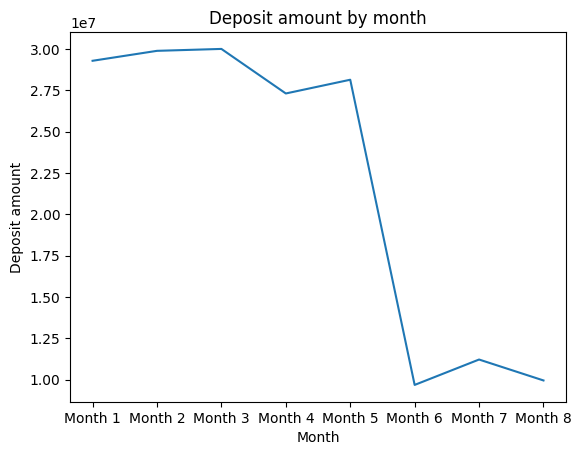

In [31]:
deposit_amount_by_month = df_copy.groupby(by=df_copy["month_name"])["deposit_amount"].sum()

print("Deposit amount per month", deposit_amount_by_month)

_ = plt.plot(deposit_amount_by_month)
_ = plt.title("Deposit amount by month")
_ = plt.ylabel("Deposit amount")
_ = plt.xlabel("Month")

The plots look a bit weird, because in months 6, 7, and 8 we have only the data coming from the new customers, and this is going to be much lower than usual.

To simulate the deposits coming from the existing customers, we can simply add an average deposit amount from the previous months.

In [32]:
avg_monthly_deposit = (df_copy.groupby(by=df_copy["month_name"])["deposit_amount"].sum()).mean()
avg_monthly_deposit

21930414.27375

month_name
Month 1    2.928483e+07
Month 2    2.988643e+07
Month 3    3.000242e+07
Month 4    2.730677e+07
Month 5    2.813815e+07
Month 6    3.160305e+07
Month 7    3.313946e+07
Month 8    3.187344e+07
Name: deposit_amount, dtype: float64


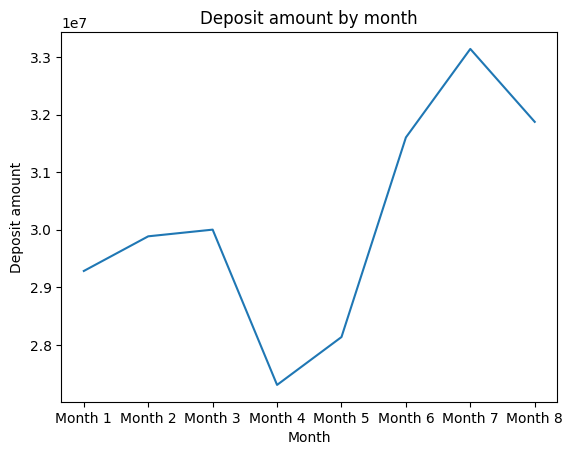

In [33]:
eposit_amount_by_month = df_copy.groupby(by=df_copy["month_name"])["deposit_amount"].sum()


deposit_amount_by_month.at["Month 6"] += avg_monthly_deposit
deposit_amount_by_month.at["Month 7"] += avg_monthly_deposit
deposit_amount_by_month.at["Month 8"] += avg_monthly_deposit

print(deposit_amount_by_month)


_ = plt.plot(deposit_amount_by_month)

_ = plt.title("Deposit amount by month")
_ = plt.ylabel("Deposit amount")
_ = plt.xlabel("Month")

The simulation shows quite an increase in deposits. Following are some key points to summarise the difference from the answer provided in **Question 1**.

- During the month the campaign was running, Freedom Debt Relief received almost $2.5 million increase in deposit amounts than previous months, compared to $10 million in **Question 1**.

- In the month following the campaign, the total deposit amount continues to increase to reach its maximum at $33 million. In the last month, it drops to $31 million but remains on a higher level than pre-campaign.

- The cost of the campaign was $5 million, and the incurred deposit amount increased by a total of $8 million. In **Question 1** this number was much higher: $26 million, and we determined that that was borderline profitable. So, $8 million is much lower, and we conclude that postponing the campaign would have not been the right choice.